<a href="https://colab.research.google.com/github/ayushpaliwal1920/Deep_Learning/blob/main/10_batch_vs_stochastic_GD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import time
import numpy as np

In [9]:
df = pd.read_csv("/Social_Network_Ads.csv")
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [10]:
x = df.iloc[:,[2,3]]
y = df.iloc[:,-1]

In [11]:
x

,Age,EstimatedSalary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000
...,...,...
395,46,41000
396,51,23000
397,50,20000
398,36,33000


In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_scaled = scaler.fit_transform(x)

In [13]:
from sklearn.model_selection import train_test_split

x_train , x_test , y_train , y_test = train_test_split(x_scaled,y,test_size=0.2,random_state =42)

In [14]:
x_train.shape

(320, 2)

In [15]:
x_scaled.shape

(400, 2)

In [16]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [17]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2))
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='sigmoid'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Batch Gradient Decent : when batch_size = n where n = number of rows of training data then it is batch gradient descent
# Stochastic Gradient Decent : when batch_size = 1 then it is Stochastic GD

model.compile(loss='binary_crossentropy',metrics = ['accuracy'])
start = time.time()
history = model.fit(x_train,y_train,epochs=10,batch_size=320,validation_split = 0.2)
print(time.time() - start)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.5039 - loss: 0.6984 - val_accuracy: 0.5625 - val_loss: 0.6966
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.5898 - loss: 0.6955 - val_accuracy: 0.6719 - val_loss: 0.6943
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.6133 - loss: 0.6933 - val_accuracy: 0.7031 - val_loss: 0.6923
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.6328 - loss: 0.6914 - val_accuracy: 0.7188 - val_loss: 0.6905
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.6523 - loss: 0.6896 - val_accuracy: 0.7188 - val_loss: 0.6888
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.6602 - loss: 0.6879 - val_accuracy: 0.7188 - val_loss: 0.6872
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.6719 - loss: 0.6862 - val_accuracy: 0.7500 - val_loss: 0.6857
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.6875 - loss: 0.6847 - val_accuracy: 0.7656 - val_loss: 0.6842
Ep

In [22]:
# Batch Gradient Decent : when batch_size = n where n = number of rows of training data then it is batch gradient descent
# Stochastic Gradient Decent : when batch_size = 1 then it is Stochastic GD

model.compile(loss='binary_crossentropy',metrics = ['accuracy'])
start = time.time()
history = model.fit(x_train,y_train,epochs=500,batch_size=1)
print(time.time() - start)

Epoch 1/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9031 - loss: 0.2715
Epoch 2/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9031 - loss: 0.2683
Epoch 3/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9031 - loss: 0.2713
Epoch 4/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9062 - loss: 0.2693
Epoch 5/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9094 - loss: 0.2699
Epoch 6/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9187 - loss: 0.2656
Epoch 7/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9094 - loss: 0.2640
Epoch 8/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9125 - loss: 0.2666
Epoch 9/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9094 - loss: 0.2638
Epoch 10/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9156 - loss: 0.2679
Epoch 11/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9156 - loss: 0.2693
Epoch 12/500
320/320 ━━━━━━━━━━━━━━━━━━━━

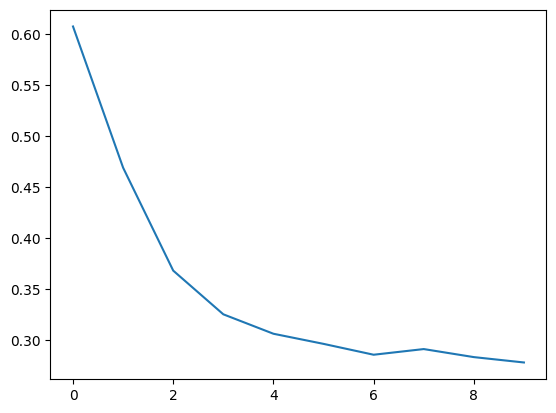

In [21]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.show()
